## Mass Number vs. Separation Energies for atoms of interest

Importing libraries and defining global constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator

#pd.options.mode.copy_on_write = False

data_filename = "separation_energy_data_table.txt"

Add functions to read in data from elements of choice

In [2]:
#read in data
def read_data(filename, skiprows = 36):
    """
    reads in data from NDS ascii files.
    note: using fortran syntax, missing uncertainty labels (which will be
    manually added in)
    note: skiprows should skip every line before header labels!
    
    returns data as usable dataframe
    """

    data = pd.read_fwf(data_filename, skiprows = 36)

    #add labels to unlabelled uncertainty columns
    data = data.rename(columns = {
        "Unnamed: 5" : "S(n) uncertainty",
        "Unnamed: 7" : "S(p) uncertainty"
    })
    
    return data

data = read_data(data_filename)

In [3]:
notable_elements = ["Be", "C"]
filtered_data = np.empty((len(notable_elements), 0))

def select_notable_elements(data, element_labels, element_label_index = 2):
    """
    filters entire data table to only show elements of choice
    element_labels is a list of element symbols (as strings!)
    assumes element label is third column of data
    
    returns dict of data frames
    """

    result = {}

    if isinstance(element_label_index, int):
        col = data.columns[element_label_index]
    else:
        col = element_label_index

    for element in element_labels:
        result[element] = data[data[col].astype(str) == element].reset_index(
            drop = True)
            
    return result

filtered_data = select_notable_elements(data, notable_elements)

Add functions to plot data

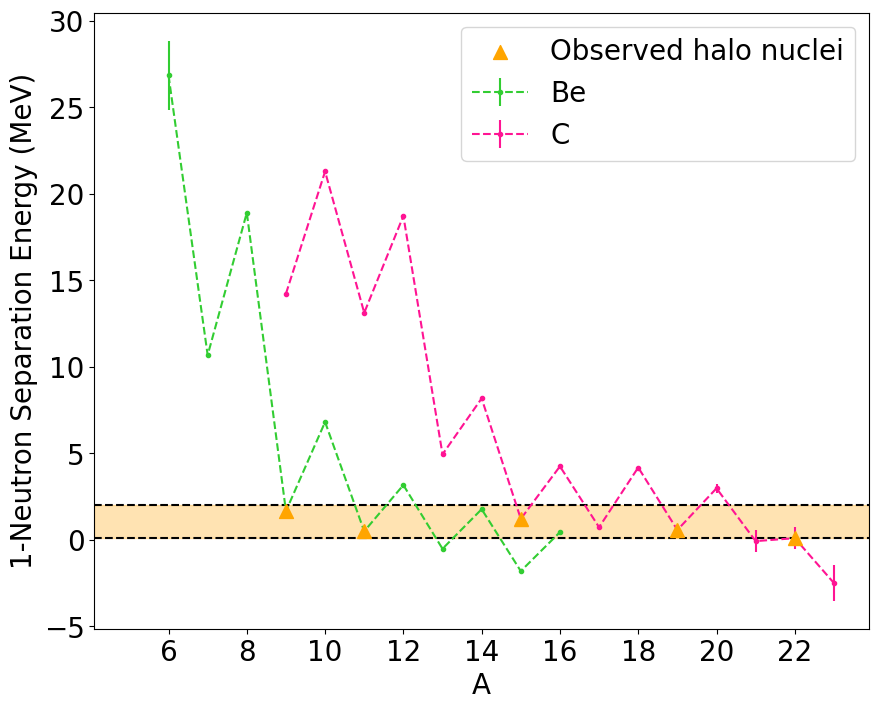

In [51]:
def plot_graph_axes():
    "plots graph axes"
    fig, ax = plt.subplots(figsize=[10,8])

    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    
    ax.set_xlabel("A", fontsize=20)
    ax.set_ylabel("1-Neutron Separation Energy (MeV)", fontsize=20)
    
    #show halo nuclei region
    ax.axhline(2, ls = "--", color = "k")
    #ax.axhline(1, ls = "--", color = "k")
    ax.axhline(0.1, ls = "--", color = "k")
    
    return ax

def validate_sn_data(data):
    """
    validates separation energy data - some uncertain measurements end in hashtags
    removes these hashtags to make S(n) data purely numeric
    """
    sn_data = data["S(n)"]
    uncertainty_data = data["S(n) uncertainty"]

    new_sn_data = []
    new_uncertainty_data = []

    for point in sn_data:
        if "#" in str(point):
            point = point.replace("#", "")
            point = float(point)
        new_sn_data.append(point)

    for point in uncertainty_data:
        if "#" in str(point):
            point = point.replace("#", "")
            point = float(point)
        new_uncertainty_data.append(point)

    sn_data.update(new_sn_data)
    uncertainty_data.update(new_uncertainty_data)
    
    return sn_data, uncertainty_data

def add_graph_data(graph, filtered_data, elements_list, colors = ['limegreen', 'deeppink']):
    """
    add the plots for the selected elements
    converts units for separation energy from keV to MeV!!
    """
    index= 0
    for element in elements_list:
        data = filtered_data[element]
        data["S(n)"], data["S(n) uncertainty"] = validate_sn_data(data)
        
        graph.errorbar(
            pd.to_numeric(data.iloc[:, 1], errors = "coerce"),
            pd.to_numeric(data.iloc[:, 4], errors = "coerce") / 1000,
            pd.to_numeric(data.iloc[:, 5], errors = "coerce") / 1000,
            marker = ".", ls = "--", label = element, color=colors[index])
        
        graph.tick_params(axis='x', labelsize='20')
        graph.tick_params(axis='y', labelsize='20')
        
#         print(pd.to_numeric(data.iloc[:, 1], errors = "coerce"))
#         print(pd.to_numeric(data.iloc[:, 4], errors = "coerce") / 1000)
        
        index +=1
        
    graph.scatter(9, 1.664539, marker='^', color='orange',zorder=10, s=100, label = "Observed halo nuclei")
    graph.plot(11, 0.501636, marker='^', color='orange',zorder=11, markersize=10)
#     graph.plot(14, 1.775895, marker='^', color='orange',zorder=12, markersize=10)
#     graph.plot(16, 0.450000, marker='^', color='orange',zorder=13, markersize=10)
    graph.plot(15, 1.218066, marker='^', color='orange',zorder=14, markersize=10)
#     graph.plot(17, 0.733572, marker='^', color='orange',zorder=15, markersize=10)
    graph.plot(19, 0.576829, marker='^', color='orange',zorder=16, markersize=10)
    graph.plot(22, 0.103000, marker='^', color='orange',zorder=16, markersize=10)
        
    plt.legend(fontsize=20)
    
    return

graph = plot_graph_axes()
add_graph_data(graph, filtered_data, notable_elements)

plt.axhspan(0.1, 2, color='orange', alpha=0.3)

plt.show()
